In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from pathlib import Path
from PIL import Image
import torch

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
data_dir = Path("../data/") 
model_dir = Path("../models/")

train_dir = data_dir / "train"
test_dir = data_dir / "test"

train_recyclable_dir = train_dir / "recyclable"
train_non_recyclable_dir = train_dir / "non_recyclable"

test_recyclable_dir = test_dir / "recyclable"
test_non_recyclable_dir = test_dir / "non_recyclable"

all_class_dirs = [train_recyclable_dir, train_non_recyclable_dir, test_recyclable_dir, test_non_recyclable_dir]

In [9]:
def walk_through_directory(directory):
    for root, dirs, files in os.walk(directory):
        print(f"There are {len(dirs)} directories and {len(files)} files in '{root}'")

print("--- Training Data Structure ---")
walk_through_directory(train_dir)

print("\n--- Test Data Structure ---")
walk_through_directory(test_dir)

--- Training Data Structure ---
There are 2 directories and 0 files in '..\data\train'
There are 0 directories and 109 files in '..\data\train\non_recyclable'
There are 0 directories and 1912 files in '..\data\train\recyclable'

--- Test Data Structure ---
There are 2 directories and 0 files in '..\data\test'
There are 0 directories and 28 files in '..\data\test\non_recyclable'
There are 0 directories and 478 files in '..\data\test\recyclable'


In [10]:
selected_dir = random.choice(all_class_dirs)
image_paths = list(selected_dir.glob("*.jpg")) + list(selected_dir.glob("*.png")) + list(selected_dir.glob("*.jpeg"))

if not image_paths:
    print(f"No images found in {selected_dir}")
else:
    image_path = random.choice(image_paths)
    label = image_path.parent.name

    print(f"Selected image path: {image_path}")

    img = Image.open(image_path)

    print(f"Image mode: {img.mode}")
    print(f"Image size: {img.size}")
    print(f"Image height: {img.height}")
    print(f"Image width: {img.width}")
    print(f"Image label: {label}")
    print(f"Image format: {img.format}")

    # img.show()

Selected image path: ..\data\train\recyclable\cardboard163.jpg
Image mode: RGB
Image size: (3264, 2448)
Image height: 2448
Image width: 3264
Image label: recyclable
Image format: JPEG


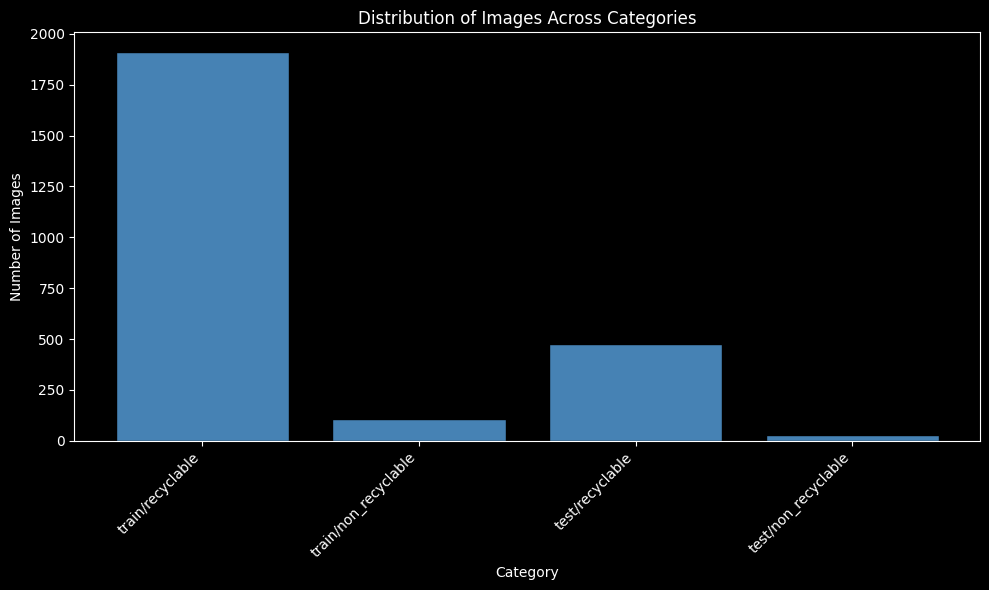


File counts per directory:
train/recyclable: 1912 images
train/non_recyclable: 109 images
test/recyclable: 478 images
test/non_recyclable: 28 images


In [11]:
dir_names = []
file_counts = []

for directory in all_class_dirs:
    images = list(directory.glob("*.jpg")) + list(directory.glob("*.png")) + list(directory.glob("*.jpeg"))
    
    # Create a clearer name like "train/recyclable"
    dir_names.append(f"{directory.parent.name}/{directory.name}") 
    file_counts.append(len(images))

plt.figure(figsize=(10, 6))
plt.bar(dir_names, file_counts, color='steelblue', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFile counts per directory:")
for name, count in zip(dir_names, file_counts):
    print(f"{name}: {count} images")

In [12]:
train_recyclable_count = file_counts[0]
train_non_recyclable_count = file_counts[1]
test_recyclable_count = file_counts[2]
test_non_recyclable_count = file_counts[3]

total_recyclable = train_recyclable_count + test_recyclable_count
total_non_recyclable = train_non_recyclable_count + test_non_recyclable_count
total_train = train_recyclable_count + train_non_recyclable_count
total_test = test_recyclable_count + test_non_recyclable_count

print(f"\n--- Train Set ({total_train} images) ---")
print(f"  Recyclable:     {train_recyclable_count} images")
print(f"  Non-recyclable: {train_non_recyclable_count} images")

print(f"\n--- Test Set ({total_test} images) ---")
print(f"  Recyclable:     {test_recyclable_count} images")
print(f"  Non-recyclable: {test_non_recyclable_count} images")

print(f"\n--- Grand Total ---")
print(f"  Total recyclable:     {total_recyclable}")
print(f"  Total non-recyclable: {total_non_recyclable}")
print(f"  Total images:         {total_train + total_test}")


--- Train Set (2021 images) ---
  Recyclable:     1912 images
  Non-recyclable: 109 images

--- Test Set (506 images) ---
  Recyclable:     478 images
  Non-recyclable: 28 images

--- Grand Total ---
  Total recyclable:     2390
  Total non-recyclable: 137
  Total images:         2527


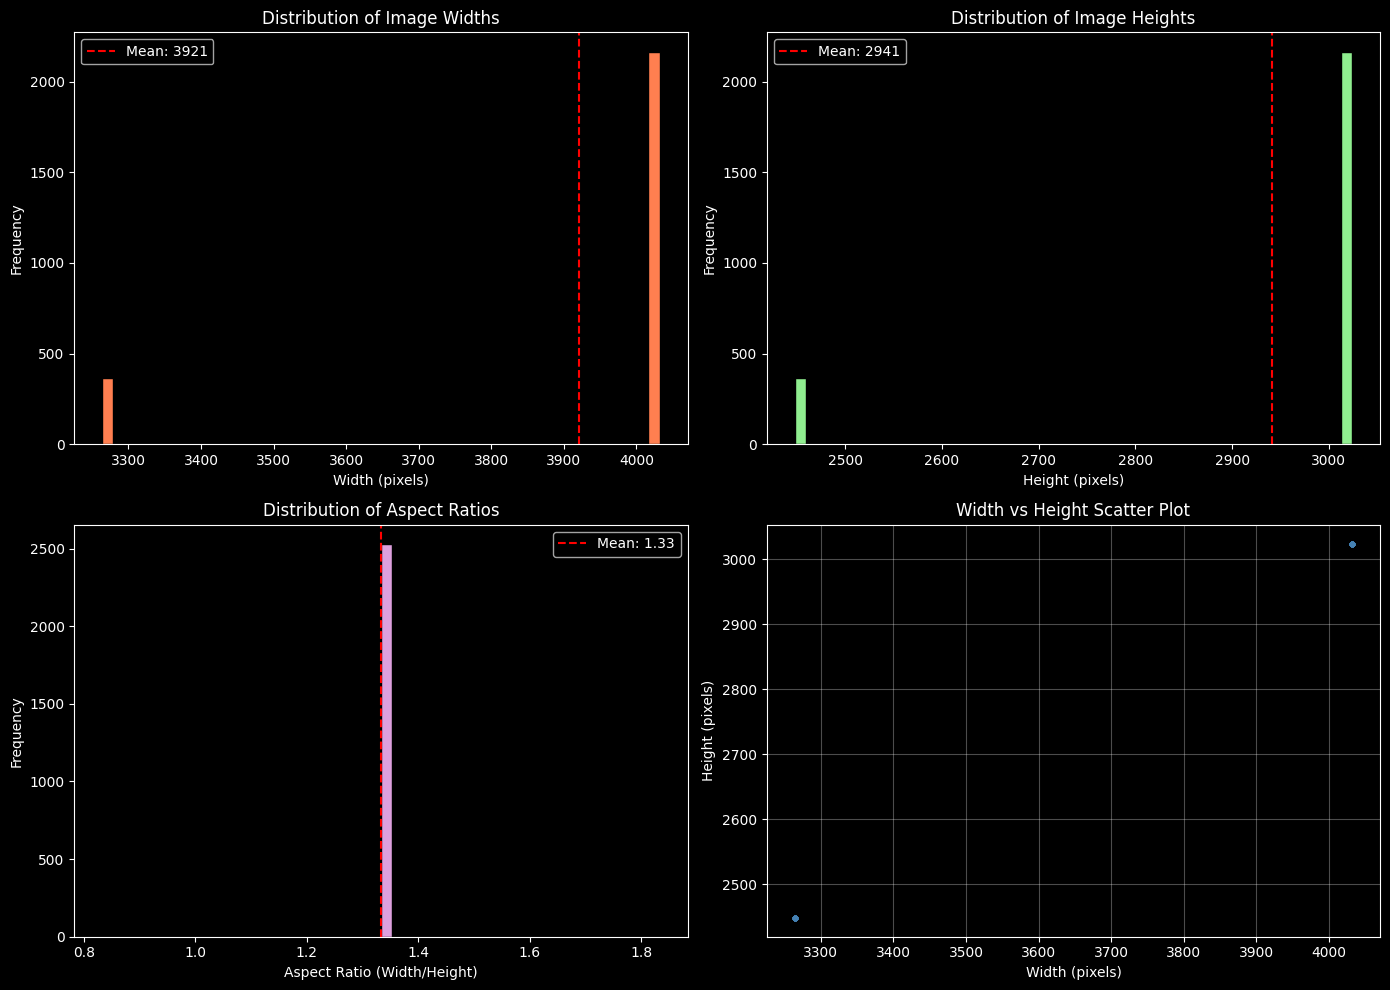


Image size statistics:
Width - Min: 3264, Max: 4032, Mean: 3921.37, Std: 269.67
Height - Min: 2448, Max: 3024, Mean: 2941.03, Std: 202.25
Aspect Ratio - Min: 1.33, Max: 1.33, Mean: 1.33
Total images analyzed: 2527


In [13]:
widths = []
heights = []
aspect_ratios = []

# Loop through all 4 class directories
for directory in all_class_dirs:
    images = list(directory.glob("*.jpg")) + list(directory.glob("*.png")) + list(directory.glob("*.jpeg"))
    
    for img_path in images:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

# Plot image size distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
axes[0, 0].hist(widths, bins=50, color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Image Widths')
axes[0, 0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0, 0].legend()

# Height distribution
axes[0, 1].hist(heights, bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Image Heights')
axes[0, 1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[0, 1].legend()

# Aspect ratio distribution
axes[1, 0].hist(aspect_ratios, bins=50, color='plum', edgecolor='black')
axes[1, 0].set_xlabel('Aspect Ratio (Width/Height)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Aspect Ratios')
axes[1, 0].axvline(np.mean(aspect_ratios), color='red', linestyle='--', label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[1, 0].legend()

# Scatter plot of width vs height
axes[1, 1].scatter(widths, heights, alpha=0.5, s=10, color='steelblue')
axes[1, 1].set_xlabel('Width (pixels)')
axes[1, 1].set_ylabel('Height (pixels)')
axes[1, 1].set_title('Width vs Height Scatter Plot')
axes[1, 1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print(f"\nImage size statistics:")
print(f"Width - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.2f}, Std: {np.std(widths):.2f}")
print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.2f}, Std: {np.std(heights):.2f}")
print(f"Aspect Ratio - Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}, Mean: {np.mean(aspect_ratios):.2f}")
print(f"Total images analyzed: {len(widths)}")

In [14]:
from utils import get_dataloaders

BATCH_SIZE = 32

try:
    cpu_count = os.cpu_count()
    if cpu_count is None:
        NUM_WORKERS = 1
    else:
        NUM_WORKERS = max(1, cpu_count // 2)
except Exception:
    NUM_WORKERS = 2

train_loader, val_loader, class_names, total_size = get_dataloaders(train_data_dir=train_dir,
                                                                  test_data_dir=test_dir,
                                                                  batch_size=BATCH_SIZE,
                                                                  num_workers=NUM_WORKERS)  
    

Dataset loaded:
  Total images: 2527
  Training images: 2021
  Validation images: 506
  Classes: ['non_recyclable', 'recyclable'] -> {'non_recyclable': 0, 'recyclable': 1}


In [15]:
train_loader, val_loader, class_names, total_size

(<torch.utils.data.dataloader.DataLoader at 0x21f47134700>,
 ['non_recyclable', 'recyclable'],
 2527)

In [16]:
# Weighted loss (This way the loss penalizes the minority classes more)

counts = torch.tensor([train_recyclable_count, train_non_recyclable_count], dtype=torch.float)
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
print("Class weights: ", weights)

Class weights:  tensor([0.1079, 1.8921])


In [17]:
import torch.nn as nn
from models import get_model

In [18]:
model_resnet = get_model(model_name="resnet50", num_classes=2, freeze_backbone=True)
model_resnet = model_resnet.to(device)

loss_resnet = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer_resnet = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)

In [19]:
model_efficientnet = get_model(model_name="efficientnet_b0", num_classes=2, freeze_backbone=True)
model_efficientnet = model_efficientnet.to(device)

loss_efficientnet = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer_efficientnet = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-4)

In [20]:
from train import train_model

history_resnet = train_model(
    model=model_resnet,
    train_loader=train_loader,
    val_loader=val_loader,
    loss=loss_resnet,
    optimizer=optimizer_resnet,
    device=device,
    num_epochs=10,
    save_path=model_dir / "resnet50_finetuned.pth"
)

Epoch 1/10
--------------------------------------------------
Batch 10/64, Loss: 0.1719
Batch 20/64, Loss: 0.0520
Batch 30/64, Loss: 0.0377
Batch 40/64, Loss: 0.0267
Batch 50/64, Loss: 0.0497
Batch 60/64, Loss: 0.0225
Train Loss: 0.0965, Train Acc: 94.06%
Val Loss: 0.0958, Val Acc: 94.47%
Best model saved with val acc: 94.47%
Epoch 2/10
--------------------------------------------------
Batch 10/64, Loss: 0.0277
Batch 20/64, Loss: 0.0376
Batch 30/64, Loss: 0.0080
Batch 40/64, Loss: 0.0246
Batch 50/64, Loss: 0.0263
Batch 60/64, Loss: 0.0158
Train Loss: 0.0241, Train Acc: 94.61%
Val Loss: 0.1006, Val Acc: 94.47%
Epoch 3/10
--------------------------------------------------
Batch 10/64, Loss: 0.0052
Batch 20/64, Loss: 0.0053
Batch 30/64, Loss: 0.0165
Batch 40/64, Loss: 0.0366
Batch 50/64, Loss: 0.0147
Batch 60/64, Loss: 0.0152
Train Loss: 0.0237, Train Acc: 94.61%
Val Loss: 0.1021, Val Acc: 94.47%
Epoch 4/10
--------------------------------------------------
Batch 10/64, Loss: 0.0276
Batc

In [21]:
from train import train_model

history_efficientnet = train_model(
    model=model_efficientnet,
    train_loader=train_loader,
    val_loader=val_loader,
    loss=loss_resnet,
    optimizer=optimizer_resnet,
    device=device,
    num_epochs=10,
    save_path=model_dir / "efficientnetb0_finetuned.pth"
)

Epoch 1/10
--------------------------------------------------
Batch 10/64, Loss: 0.6720
Batch 20/64, Loss: 0.7396
Batch 30/64, Loss: 0.7221
Batch 40/64, Loss: 0.6618
Batch 50/64, Loss: 0.6910
Batch 60/64, Loss: 0.6808
Train Loss: 0.6950, Train Acc: 53.29%
Val Loss: 0.6965, Val Acc: 51.38%
Best model saved with val acc: 51.38%
Epoch 2/10
--------------------------------------------------
Batch 10/64, Loss: 0.6893
Batch 20/64, Loss: 0.7072
Batch 30/64, Loss: 0.6934
Batch 40/64, Loss: 0.6972
Batch 50/64, Loss: 0.6924
Batch 60/64, Loss: 0.6977
Train Loss: 0.6932, Train Acc: 52.89%
Val Loss: 0.6943, Val Acc: 51.98%
Best model saved with val acc: 51.98%
Epoch 3/10
--------------------------------------------------
Batch 10/64, Loss: 0.7145
Batch 20/64, Loss: 0.7014
Batch 30/64, Loss: 0.6812
Batch 40/64, Loss: 0.7368
Batch 50/64, Loss: 0.7078
Batch 60/64, Loss: 0.7170
Train Loss: 0.6973, Train Acc: 52.55%
Val Loss: 0.6926, Val Acc: 52.37%
Best model saved with val acc: 52.37%
Epoch 4/10
-----

In [24]:
history_efficientnet

{'train_loss': [0.6950330270628479,
  0.6932303392020032,
  0.6972803192407645,
  0.6955665582657332,
  0.695448064379383,
  0.6933683335987546,
  0.6927072248324376,
  0.6941252449607566,
  0.69641626804315,
  0.6963892547226613],
 'train_acc': [53.2904502721425,
  52.894606630381,
  52.54824344383968,
  52.4987629886195,
  52.39980207817912,
  53.68629391390401,
  54.03265710044533,
  52.79564571994062,
  52.449282533399305,
  53.14200890648194],
 'val_loss': [0.6964577207923407,
  0.6942653038756178,
  0.6925704870299388,
  0.6932491269036244,
  0.7061223432480582,
  0.696214604754693,
  0.696418714617552,
  0.7002216572818077,
  0.7001399996252399,
  0.6810237904311168],
 'val_acc': [51.383399209486164,
  51.976284584980235,
  52.37154150197628,
  52.17391304347826,
  47.62845849802372,
  50.790513833992094,
  49.60474308300395,
  49.40711462450593,
  49.209486166007906,
  55.92885375494071]}

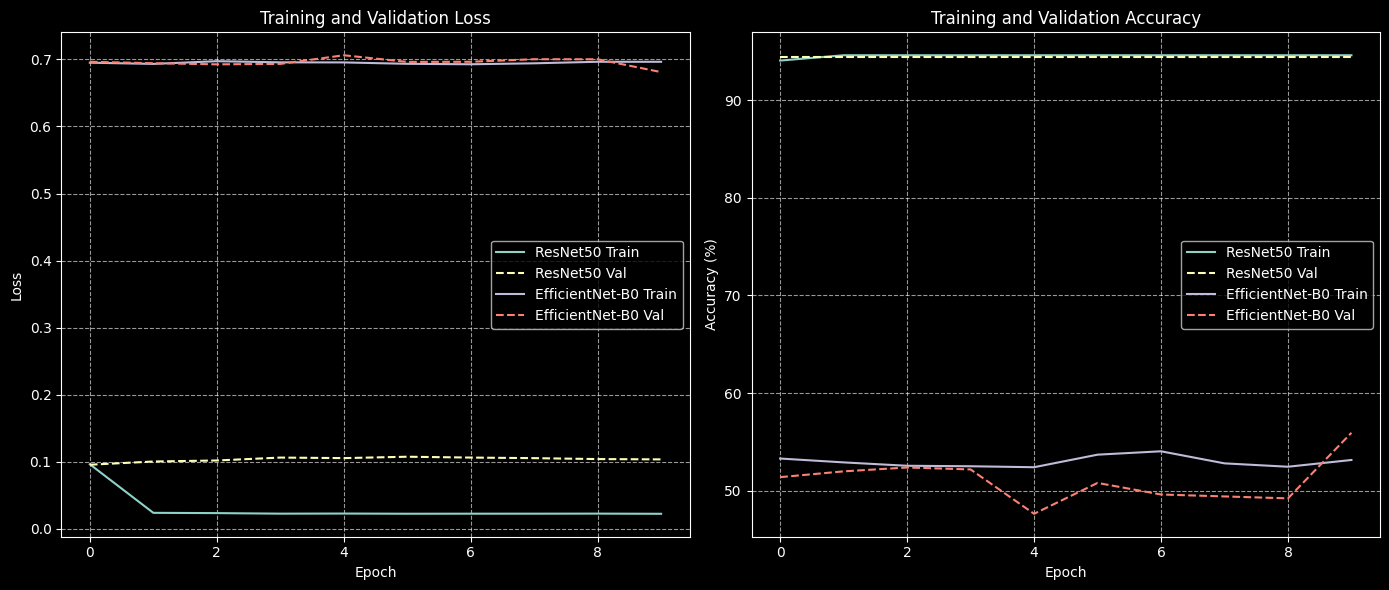

In [25]:
from utils import plot_training_history

plot_training_history(histories=[history_resnet,history_efficientnet], model_names=["ResNet50", "EfficientNet-B0"])
